# Implementation details
This implementation will follow the standard Canny edge detection algorithm:
1. Smooth the image
2. Compute gradients, magnitude, and orientation of the gradient
3. Perform non-maximum suppression
4. Apply hysteresis thresholding 

# Ingest image
Read a grascale image and store it in a matrix $I$

float64
[[ 40.  42.  35. ...  12.  10.  11.]
 [ 61.  63.  59. ...  12.  10.  11.]
 [ 57.  58.  56. ...  11.  11.  11.]
 ...
 [ 96. 120. 126. ...  25.  29.  24.]
 [123. 128. 127. ...  32.  28.  23.]
 [132. 127. 123. ...  30.  27.  24.]]


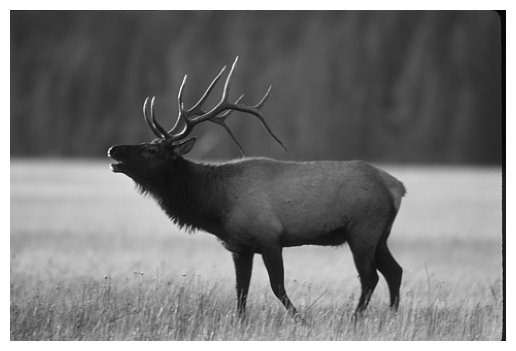

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image as a 2D grayscale, store floats
img_path = 'images/elk.jpg'
I = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
I = I.astype(np.float64)

# Output basic info
print(I.dtype)
print(I)

# Display with matplotlib
plt.imshow(I, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

# Construct the Gaussian derivative

Pre-differentiating the Gaussian offers significant speed improvements.

These calculations provide a single filter kernel that can be convolved with the image.

## Why pre-differentiate?

Smoothing with a Gaussian $G$ and then differentiating is the same as convolving once with the derivative of the Gaussian:

$$
\frac{\partial}{\partial x}\,(G * I) \;=\; \left(\frac{\partial G}{\partial x}\right) * I
$$

So instead of two passes (blur, then differentiate), we build one kernel $\frac{\partial G}{\partial x}$ ahead of time and apply it once.

## Step 1: Sample positions

The Gaussian never reaches zero, so we truncate at $3\sigma$:

$$
r = \lceil 3\sigma \rceil, \qquad x \in \{-r, -r+1, \dots, 0, \dots, r-1, r\}
$$

The kernel has $2r + 1$ elements (7 when $\sigma = 1$).

## Step 2: Gaussian kernel

$$
G_{\text{raw}}(x) = \exp\!\left(-\frac{x^2}{2\sigma^2}\right)
$$

We normalize numerically so the weights sum to 1 (a true weighted average, so brightness is preserved):

$$
G(x) = \frac{G_{\text{raw}}(x)}{\sum_{k=-r}^{r} G_{\text{raw}}(k)}, \qquad \sum_{x} G(x) = 1
$$

## Step 3: Derivative kernel

Differentiating the Gaussian with the chain rule:

$$
\frac{d}{dx}\exp\!\left(-\frac{x^2}{2\sigma^2}\right)
= -\frac{x}{\sigma^2}\exp\!\left(-\frac{x^2}{2\sigma^2}\right)
$$

so, reusing the normalized $G$:

$$
\frac{dG}{dx}(x) = -\frac{x}{\sigma^2}\,G(x)
$$

## Step 4: Applying along each axis

The same 1D coefficients are used for both directions. The 2D Gaussian is separable, $G(x,y) = G(x)\,G(y)$, so:

$$
I_x = I * \left(\frac{dG}{dx}\ \text{along } x,\ \ G\ \text{along } y\right), \qquad
I_y = I * \left(G\ \text{along } x,\ \ \frac{dG}{dy}\ \text{along } y\right)
$$

Two 1D passes cost $O(N)$ per pixel instead of $O(N^2)$ for a full 2D kernel.

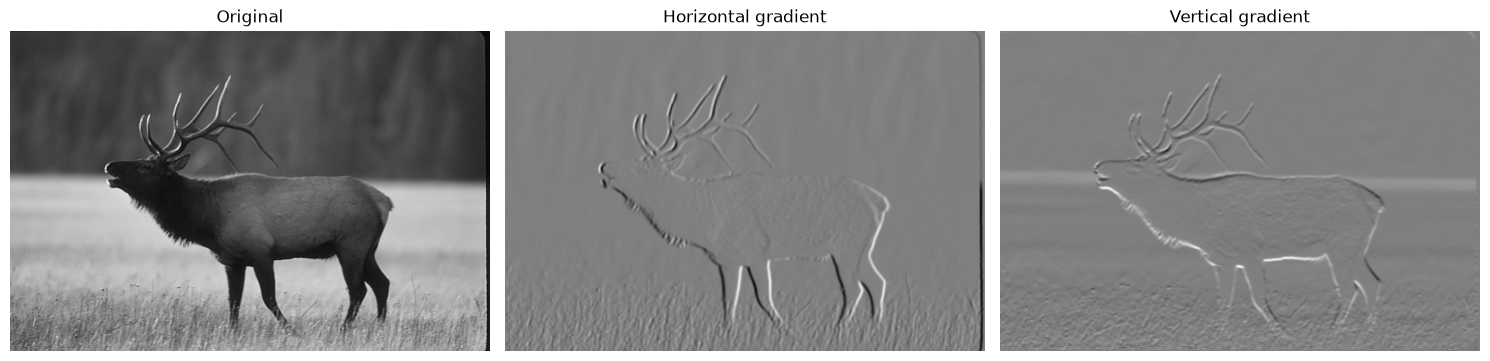

In [31]:
sigma = 1.0
kernel_radius = int(np.ceil(3 * sigma))
# Generate numpy array within the kernel radius
x = np.arange(-kernel_radius, kernel_radius+1, dtype=np.float64)

# Normalize Gaussian kernel
G = np.exp(-x**2 / (2 * sigma**2))
G /= G.sum()

# Use the differentiated Gaussian
# G(x,y) = G(x)G(y), so the same 1D arrays serve both axes:
#   Ix: dG along x, G along y
#   Iy: dG along y, G along x
dG = -(x / sigma**2) * G


def convolve(image, kernel, axis):
    """
    Convolve a 2D image with a 1D kernel along a specified axis
      axis = 0 -> vertical   (neighbors above/below, same column)
      axis = 1 -> horizontal (neighbors left/right, same row)
    """
    height, width = image.shape
    kernel_length = len(kernel)
    kernel_radius = kernel_length // 2

    # Pad the borders
    # Pixels near the edge need neighbors that don't exist
    if axis == 0:
        padding = [(kernel_radius, kernel_radius), (0, 0)]
    else:
        padding = [(0, 0), (kernel_radius, kernel_radius)]

    padded = np.pad(image, padding, mode="reflect")

    # Flip the kernel to perform convolution
    flipped_kernel = kernel[ : : -1]

    result = np.zeros((height, width), dtype=np.float64)

    for k in range(kernel_length):
        weight = flipped_kernel[k]

        if axis == 0:
            shifted_image = padded[k : k + height, :]
        else:
            shifted_image = padded[:, k : k + width]

        # For each pixel, store weight * neighbor at this offset
        result += weight * shifted_image

    return result


# Vertical smoothing
Ix = convolve(I, G, axis=0)
# Horizontal smoothing
Iy = convolve(I, G, axis=1)
# Horizontal derivative
Ix_prime = convolve(Ix, dG, axis=1)
# Vertical derivative
Iy_prime = convolve(Iy, dG, axis=0)


# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(I, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
limit = max(np.abs(Ix_prime).max(), np.abs(Iy_prime).max())
axes[1].imshow(Ix_prime, cmap="gray", vmin=-limit, vmax=limit)
axes[1].set_title("Horizontal gradient")
axes[2].imshow(Iy_prime, cmap="gray", vmin=-limit, vmax=limit)
axes[2].set_title("Vertical gradient")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Gradient magnitude

From the steps above, the gradient magnitude and direction used by Canny are then:
$$
|\nabla I| = \sqrt{I_x^2 + I_y^2}, \qquad \theta = \operatorname{atan2}(I_y,\, I_x)
$$

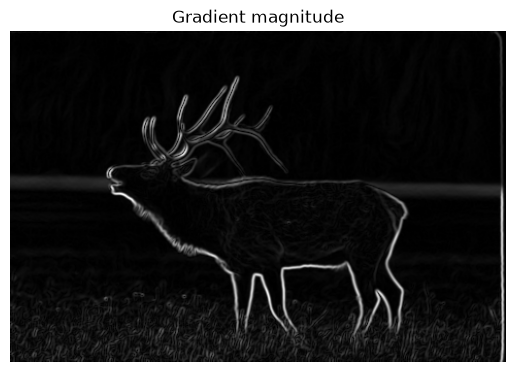

In [32]:
# Gradient magnitude
M = np.hypot(Ix_prime, Iy_prime)

# Orientation
theta = np.arctan2(Iy_prime, Ix_prime)

plt.imshow(M, cmap='gray', vmin=0)
plt.title('Gradient magnitude')
plt.axis('off')
plt.show()

# Non-maximum suppression
The goal here is to remove false-positive edge locations from the image. The technique essentially makes edge boundaries thinner.

Some key pointers:
- The gradient is perpendicular to the edge.
- Compare magnitudes on either side in that direction.
- Suppres the center unless it is a strict maximum.
- Interpolation handles position between pixels.

I used interpolation here for more accurate gradient direction handling. I could have otherwise rounded to a couple directions.

In [52]:
def bilinear(image, y, x):
    """
    Approximates the value at a certain point in a grid
    Samples 4 coordinates with known values
    Takes a weighted average of the 4 surrounding points
    """
    height, width = image.shape

    # Known points: (x0, y0), (x0, y1), (x1, y0), (x1, y1)
    x0 = np.floor(x).astype(np.intp)
    y0 = np.floor(y).astype(np.intp)
    x1 = min(x0 + 1, width -1)
    y1 = min(y0 + 1, height - 1)

    right_weight = x - x0
    bottom_weight = y - y0
    left_weight = 1 - right_weight
    top_weight = 1 - bottom_weight

    return (
        top_weight * left_weight * image[y0, x0]
        + top_weight * right_weight * image[y0, x1]
        + bottom_weight * left_weight * image[y1, x0]
        + bottom_weight * right_weight * image[y1, x1]
    )

def non_maximum_suppression(M, theta):
    """
    Keep strict local maxima along the gradient
    Leave borders zero
    """

    height, width = M.shape

    # Initialized with all pixels suppressed
    suppressed = np.zeros_like(M)

    # Skip borders to compare within the image
    for y in range(1, height - 1):
        for x in range(1, width - 1):
            # Convert angle into horizontal and vertical direction offsets
            dx = np.cos(theta[y, x])
            dy = np.sin(theta[y, x])

            # Extend the direction until its largest component is a single pixel
            scale = max(abs(dx), abs(dy))
            dx /= scale
            dy /= scale

            # Estimate magnitudes on both sides along the gradient direction
            # Bilinear interpolation handles points between point centers
            forward = bilinear(M, y + dy, x + dx)
            backward = bilinear(M, y - dy, x - dx)

            # Keep the center only if it is stronger than both comparisons
            if M[y, x] >= forward and M[y, x] > backward:
                suppressed[y, x] = M[y, x]

    return suppressed


N = non_maximum_suppression(M, theta)

# Hysteresis thresholding
Start from every strong pixel.

Follow chains of neighboring pixels that meet the low threshold.

Weak pixels disconnected from strong pixels are discarded.

In [ ]:
def hysteresis(N, low, high):
    """
    Keep 8-connected candidate regions containing a strong pixel
    N is magnitude image after non-maximum suppression
    low and high define the threshold to consider a pixel an edge pixel
    """
    if 0 < low < high:
        # Select possible edge pixels, at or above lower bound
        candidates = (N >= low).astype(np.uint8)

        # Assign each connected region a label, label 0 is reserved for background
        count, labels = cv2.connectedComponents(candidates, connectivity=8)

        # Identify regions containing at least one strong pixel
        strong_labels = np.unique(labels[N >= high])

        # Create a lookup table of accepted groups
        keep = np.zeros(count, dtype=bool)
        keep[strong_labels] = True

        # Map retained region labels back to a binary edge image
        return keep[labels]
    
    else:
        raise ValueError("Requires 0 < low < high")

# Check that magnitudes remain after non-max suppression
if N.max() > 0:
    # Set high threshold to 20% of the max magnitude
    high = 0.20 * N.max()
    # Set low threshold to 10% of the maximum magnitude
    low = 0.50 * high
    edges = hysteresis(N, low, high)
# Return an empty edge map when all responses are zero
else:
    edges = np.zeros_like(N, dtype=bool)

# Display progression

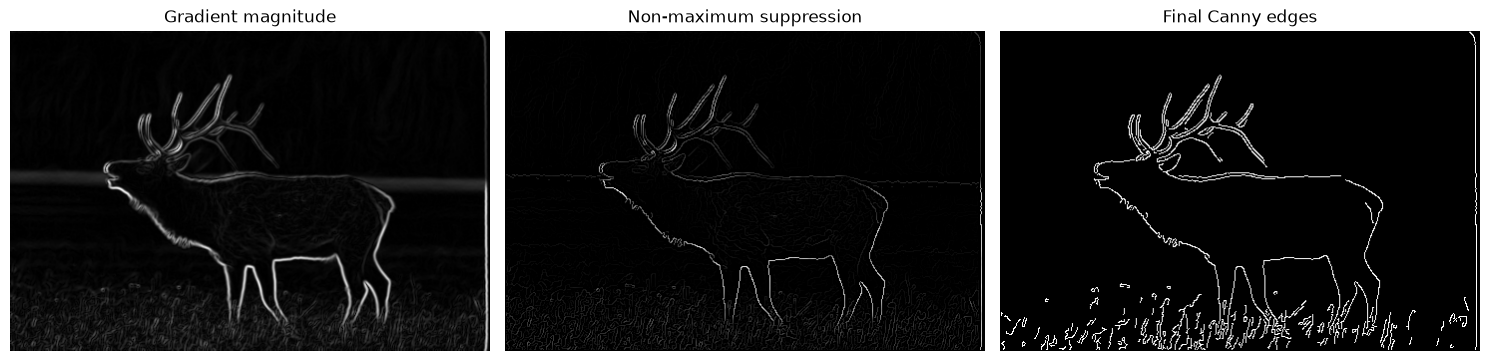

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, image, title in zip(
    axes,
    [M, N, edges],
    ["Gradient magnitude", "Non-maximum suppression", "Final Canny edges"],
):
    ax.imshow(image, cmap="gray", vmin=0,
              vmax=1 if image.dtype == bool else M.max())
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()